# Ingeniería de caracteristicas
### Autor: Diego Sánchez de la Fuente

In [1]:
# Imports necesarios core
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
# Para graficar
from matplotlib import pyplot as plt
import plotly.express as px
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
# Estadistica
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp

In [4]:
# Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor

In [48]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Lasso
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.impute import SimpleImputer

In [6]:
import joblib

In [7]:
df_tablon = pd.read_parquet("../data/processed/final/tablon_model_ready_full_plus_nlp.parquet")

In [8]:
print(f"Forma del dataset {df_tablon.shape}")
print(f"---------------------------------------------")
print(f"Primera fila del dataset {df_tablon.head(1)}")
print(f"---------------------------------------------")
print(f"Features del dataset {df_tablon.columns}")
print(f"---------------------------------------------")

Forma del dataset (2000, 34)
---------------------------------------------
Primera fila del dataset    roi_proxy_v3  roi_class_v3  cost_proxy_v2  pub_year  family_size_simple  \
0      4.446525             2       4.418429      2023                  16   

   legal_has_grant_like  legal_has_opposition_like  is_active_recent  \
0                     1                          0                 1   

   log_legal_events_count  log_legal_codes_unique  ...  \
0                2.944439                2.397895  ...   

   log_party_applicant_count  ops_pub_date  ops_n_cpc  tech_breadth_proxy  \
0                   1.098612      20231227         20            3.044522   

   log_family_size  sim_claims_abstract  semantic_novelty  sim_to_high_roi  \
0         2.833213             0.802872          0.340721         1.895355   

   novelty_x_family  novelty_x_breadth  
0          0.965336           1.037333  

[1 rows x 34 columns]
---------------------------------------------
Features del datas

In [9]:
df = df_tablon.copy()

# Distribución proxy_roi_v3

In [10]:
print("Estadisticos del proxy_roi_v3")
df["roi_proxy_v3"].describe()

Estadisticos del proxy_roi_v3


count    2000.000000
mean        3.967584
std         0.752222
min         1.791216
25%         3.425849
50%         4.007120
75%         4.443528
max         9.781286
Name: roi_proxy_v3, dtype: float64

### Historigrama frente a boxplot proxy_roi_v3

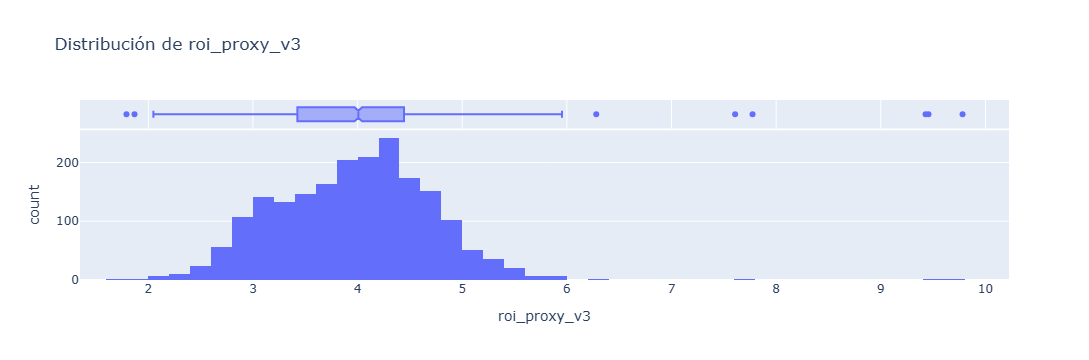

In [11]:
fig = px.histogram(
    df,
    x="roi_proxy_v3",
    nbins=60,
    marginal="box",
    title="Distribución de roi_proxy_v3"
)

fig.show()

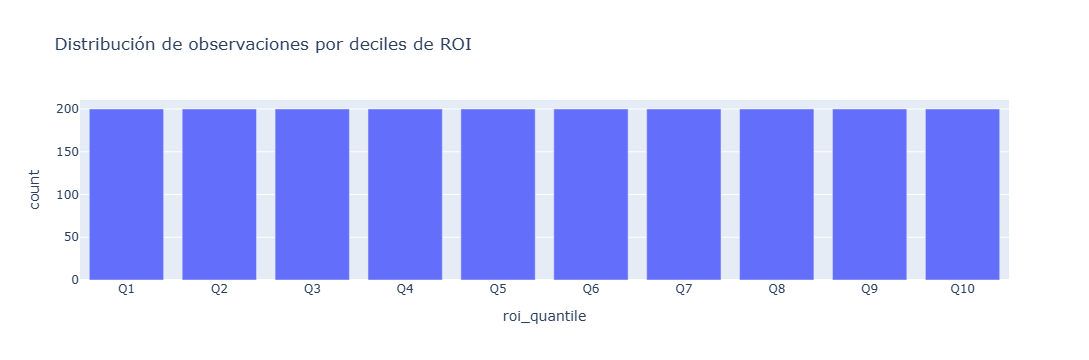

In [12]:
df["roi_quantile"] = pd.qcut(
    df["roi_proxy_v3"],
    q=10,
    labels=[f"Q{i}" for i in range(1, 11)]
)

fig = px.bar(
    df["roi_quantile"].value_counts().sort_index().reset_index(),
    x="roi_quantile",
    y="count",
    title="Distribución de observaciones por deciles de ROI"
)

fig.show()

## Balanceo de clases con ayuda de class_roi_v3

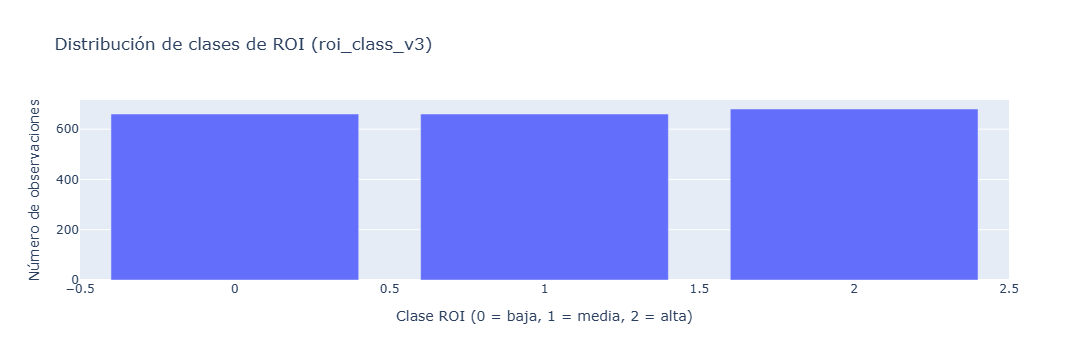

In [13]:
fig = px.bar(
    df["roi_class_v3"].value_counts()
      .sort_index()
      .reset_index(),
    x="roi_class_v3",
    y="count",
    title="Distribución de clases de ROI (roi_class_v3)",
    labels={
        "roi_class_v3": "Clase ROI (0 = baja, 1 = media, 2 = alta)",
        "count": "Número de observaciones"
    }
)

fig.show()

## Visualización de cohortes en la distribución de roi_proxy_v3

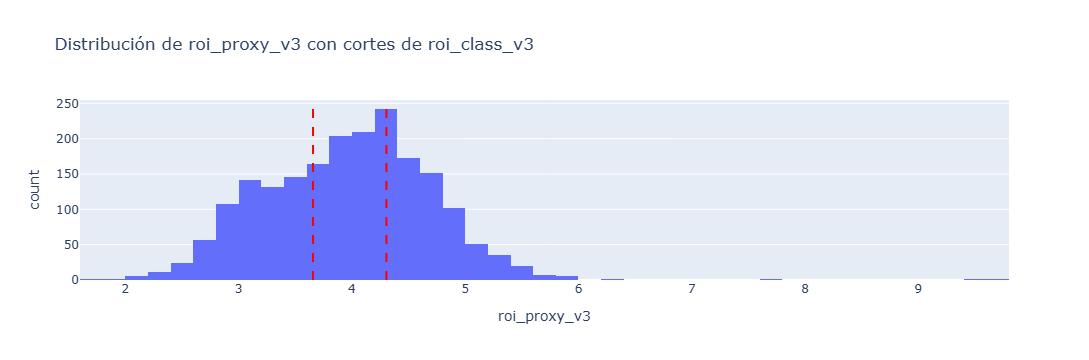

In [14]:
cuts = df["roi_proxy_v3"].quantile([1/3, 2/3]).values

fig = px.histogram(
    df,
    x="roi_proxy_v3",
    nbins=60,
    title="Distribución de roi_proxy_v3 con cortes de roi_class_v3"
)

for c in cuts:
    fig.add_vline(x=c, line_dash="dash", line_color="red")

fig.show()

La variable `roi_class_v3` se ha definido mediante discretización por cuantiles del ROI continuo (`roi_proxy_v3`). Este procedimiento garantiza un número similar de observaciones en cada clase, lo que explica la distribución aparentemente balanceada observada en los gráficos. Las clases representan niveles relativos de retorno económico dentro del conjunto de datos, y no umbrales absolutos, facilitando así el entrenamiento y la evaluación de modelos de clasificación.

# Matriz de correlación Spearman

In [15]:
target = "roi_proxy_v3"

features = (
    df
    .select_dtypes(include="number")
    .drop(columns=[target], errors="ignore")
    .loc[:, lambda d: d.notna().any()]        # no todo NaN
    .loc[:, lambda d: (d != 0).any()]          # no todo ceros
    .columns
    .tolist()
)

features.remove('pub_year')


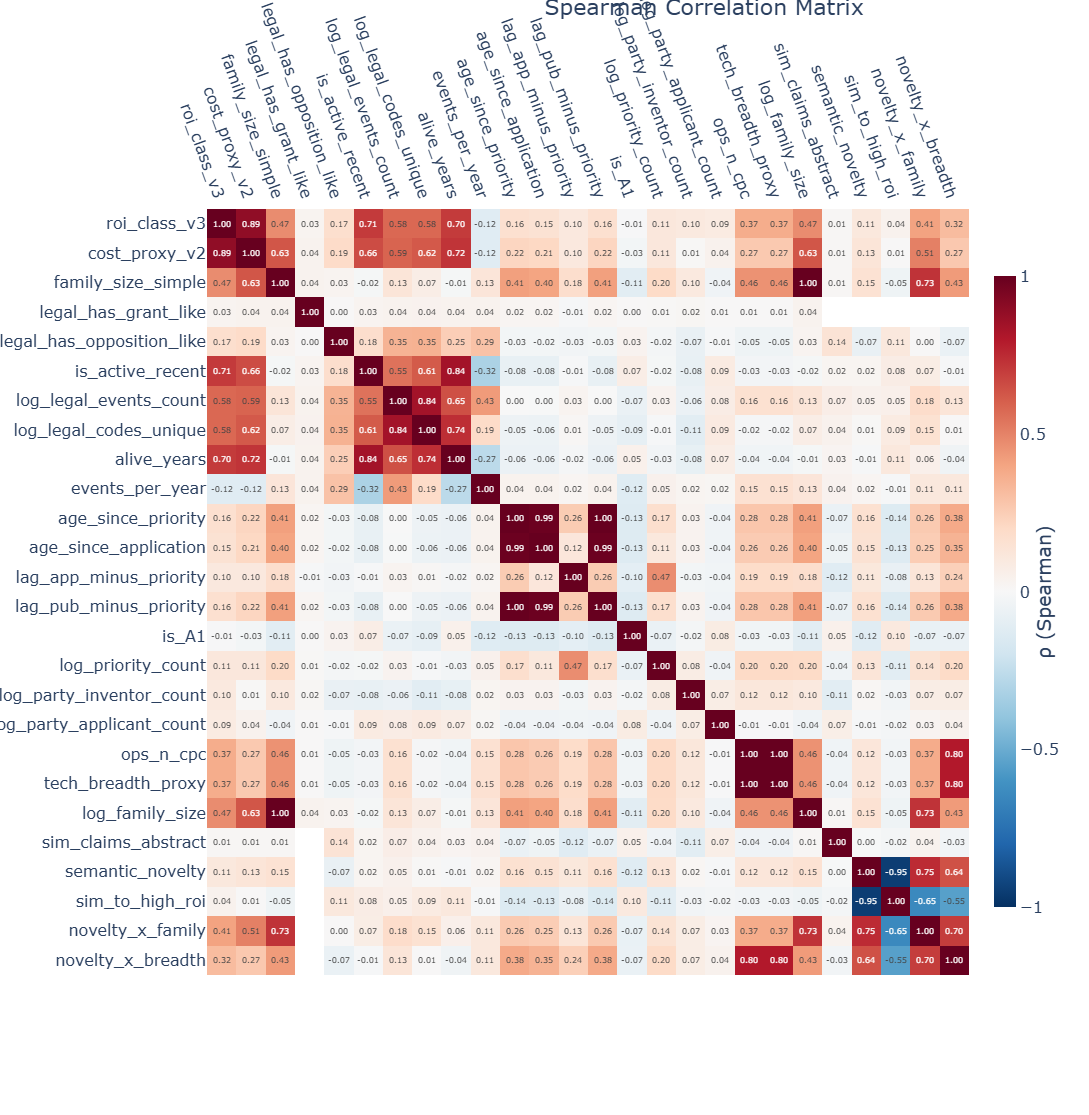

In [16]:
corr = df[features].corr(method="spearman")
TH = 0.4  # umbral de "correlación relevante"
mask = (corr.abs() >= TH).any(axis=0)
corr_reduced = corr.loc[mask, mask]


fig = px.imshow(
    corr_reduced,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    aspect="auto",
    title="Spearman Correlation Matrix"
)

fig.update_layout(
    width=1200,
    height=1100,
    font=dict(size=16),
    margin=dict(l=140, r=120, t=120, b=140),
    paper_bgcolor="white",
    plot_bgcolor="white",
    coloraxis_colorbar=dict(
        title=dict(text="ρ (Spearman)", side="right"),
        len=0.85,
        thickness=22
    )
)

# Ejes: etiquetas arriba y rotación para que quepan
fig.update_xaxes(
    side="top",
    tickangle=70,
    showgrid=False,
    zeroline=False
)
fig.update_yaxes(
    tickangle=0,
    showgrid=False,
    zeroline=False
)

fig.update_layout(
    title=dict(
        y=1,          # ⬅️ sube el título
        x=0.5,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(t=140)   # ⬅️ más espacio superior
)

# Hover limpio
fig.update_traces(hovertemplate="ρ = %{z:.2f}<extra></extra>")

fig.show()


## Matriz de correlación (Spearman)

Se ha calculado la matriz de correlación de Spearman entre las variables explicativas y el proxy de retorno económico (`roi_proxy_v3`).

Se utiliza **Spearman (ρ)** en lugar de Pearson porque:
- muchas variables son **asimétricas o discretas**
- el interés principal es detectar **relaciones monótonas**, no necesariamente lineales
- es más robusta frente a outliers, habituales en datos de patentes

### Relación con la variable objetivo (`roi_proxy_v3`)

Las correlaciones observadas reflejan patrones coherentes con la lógica económica y jurídica de la explotación de patentes:

- **`is_active_recent` (ρ ≈ 0.72)**  
  Indica si la patente mantiene actividad legal reciente. Presenta una correlación elevada con el ROI, lo que sugiere que las patentes activas tienden a conservar valor económico.

- **`alive_years` (ρ ≈ 0.72)**  
  Captura la duración efectiva de la patente. Una mayor longevidad se asocia a una explotación sostenida en el tiempo.

- **`log_legal_events_count` (ρ ≈ 0.60)**  
  Refleja la intensidad de eventos legales (oposiciones, cambios de estado, etc.), interpretables como señales indirectas de interés económico.

- **`log_family_size` (ρ ≈ 0.56)**  
  Las familias de mayor tamaño suelen implicar una estrategia de protección más amplia, asociada a mayor inversión y potencial retorno.

### Variables compuestas e interacciones

- **`novelty_x_breadth` (ρ ≈ 0.38)**  
  Combina novedad semántica con amplitud tecnológica. Aporta información adicional frente a sus componentes individuales, aunque muestra alta correlación con métricas de amplitud tecnológica.

- **`novelty_x_family` (ρ ≈ 0.47)**  
  Interacción entre novedad y tamaño de familia. Refuerza la señal cuando la innovación se acompaña de una protección extensa.

### Variables con baja correlación directa

Variables como:
- `log_priority_count`
- `log_party_applicant_count`
- `log_party_inventor_count`

presentan correlaciones moderadas o bajas, pero pueden aportar valor explicativo complementario en modelos multivariantes.

### Variables sin relación significativa

- **`ops_pub_date`**
- **`events_per_year`**

No muestran relación clara con el ROI y se excluyen del modelado inicial.

### Colinealidad entre variables

Se identifican bloques con alta correlación interna:
- Variables de **vida y actividad** (`is_active_recent`, `alive_years`, `log_legal_events_count`)
- Variables de **amplitud tecnológica** (`tech_breadth_proxy`, `ops_n_cpc`, `novelty_x_breadth`)

Por este motivo, se propone una selección cuidadosa de variables para evitar multicolinealidad en modelos de regresión lineales.


## Gestión de la colinealidad mediante regularización (Opción B)

El análisis de correlación revela la existencia de una colinealidad significativa dentro del subgrupo de variables legales, en particular entre las métricas de intensidad de actividad legal y las variables temporales asociadas a la duración del historial jurídico. Estas dependencias reflejan relaciones estructurales reales del fenómeno analizado, por lo que su eliminación directa podría suponer una pérdida de información relevante.

En lugar de descartar estas variables de forma manual, se adopta un enfoque basado en **regularización explícita**, permitiendo que el propio modelo gestione la redundancia informativa entre predictores correlacionados. Este enfoque resulta especialmente adecuado en presencia de:

- variables altamente correlacionadas que capturan dimensiones latentes comunes,
- señales explicativas de distinta naturaleza (tecnológica, legal, temporal y textual),
- y un objetivo continuo susceptible a sobreajuste.

En este contexto, se emplean modelos de regresión regularizados (OLS, Lasso, Ridge y Elastic Net), que introducen una penalización sobre la magnitud de los coeficientes. Esta penalización favorece soluciones más estables y evita que pequeñas variaciones en los datos produzcan cambios abruptos en los pesos asociados a variables colineales.

Concretamente, se mantienen simultáneamente las siguientes variables legales:
- métricas de intensidad jurídica (`log_legal_events_count`),
- métricas temporales de persistencia (`alive_years`),
- e indicadores de vigencia reciente (`is_active_recent`),

permitiendo que la regularización distribuya el peso explicativo entre ellas en función de su contribución marginal al retorno económico.

Este planteamiento permite:
- preservar la información contenida en variables correlacionadas,
- reducir el riesgo de sobreajuste,
- y analizar posteriormente la estabilidad y relevancia de los coeficientes estimados como parte del análisis de sensibilidad del modelo.

En fases posteriores, los resultados obtenidos mediante regularización se comparan con modelos más parsimoniosos basados en selección manual de variables, con el fin de evaluar la robustez de las conclusiones.


In [17]:
features_base = [
    "is_active_recent",          # señal fuerte de vigencia
    "log_legal_events_count",    # intensidad jurídica
    "log_family_size",           # estrategia de protección
    "novelty_x_breadth",         # innovación con alcance
]


features_extended = [
    "is_active_recent",
    "log_legal_events_count",
    "log_family_size",
    "novelty_x_breadth",
    "novelty_x_family",
    "log_priority_count",
    "log_party_applicant_count",
]

## Análisis de valores extremos (outliers)

Antes de proceder al modelado, se ha realizado un análisis específico de valores extremos con el objetivo de identificar observaciones atípicas, evaluar su naturaleza y determinar su posible impacto en el modelo. Este análisis se aborda desde una perspectiva exploratoria, evitando la eliminación automática de observaciones y priorizando la interpretación económica y estructural de los outliers.

### Identificación univariante de outliers

La detección inicial de valores extremos se realiza mediante diagramas de caja (boxplots) y distribuciones marginales de las principales variables continuas, incluyendo el ROI y los predictores transformados logarítmicamente. Estas visualizaciones permiten observar:

- distribuciones asimétricas con colas largas, especialmente en variables relacionadas con la actividad legal y el tamaño de la familia de patentes,
- la presencia de observaciones extremas aisladas,
- y la efectividad de las transformaciones logarítmicas (`log1p`) para reducir la influencia de valores muy grandes.

Este comportamiento es consistente con la naturaleza del dominio, donde un número reducido de patentes concentra niveles excepcionalmente altos de actividad legal o retorno económico.

### Outliers bivariantes y relación con el ROI

El análisis de dispersión entre variables explicativas y el ROI permite distinguir entre distintos tipos de outliers:

- **outliers informativos**, caracterizados por valores extremos de predictores asociados a altos niveles de ROI, que reflejan patentes de elevado valor estratégico;
- **outliers neutros o de bajo impacto**, que no alteran de forma significativa la relación global entre variables;
- y posibles **anomalías**, que pueden corresponder a errores de registro o casos muy particulares.

En particular, se observa que muchos valores extremos en variables legales y temporales se corresponden con patentes con historial jurídico prolongado o intensa actividad reciente, lo que refuerza su interpretación como casos relevantes y no como ruido estadístico.

### Enfoque adoptado para el modelado

Dado que los valores extremos observados están alineados con la lógica económica y jurídica del fenómeno analizado, se opta por **no eliminar outliers de forma sistemática**. En su lugar, se adoptan estrategias que permiten gestionar su impacto de manera controlada:

- uso de transformaciones logarítmicas para estabilizar la varianza,
- empleo de coeficientes de correlación robustos (Spearman),
- y aplicación de técnicas de regularización en la fase de modelado para reducir la sensibilidad a observaciones extremas.

Este enfoque permite preservar información potencialmente valiosa contenida en los outliers, al tiempo que se limita su influencia desproporcionada en la estimación de los modelos.

### Implicaciones

El análisis de outliers confirma que la heterogeneidad observada en el conjunto de datos es una característica inherente al dominio de las patentes y del retorno económico. Por tanto, los valores extremos se interpretan mayoritariamente como **señales estructurales** más que como ruido, justificando su inclusión controlada en el proceso de modelado.


## Análisis features Modelo base

In [18]:
df_modelo_extendido = df[features_extended + ['roi_proxy_v3']]
df_modelo_base = df[features_base + ['roi_proxy_v3']]

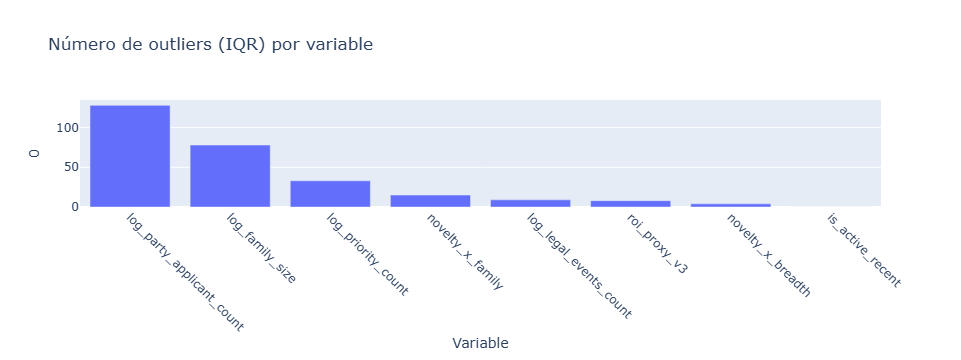

In [19]:
def iqr_outlier_flags(df, cols, k=1.5):
    flags = pd.DataFrame(index=df.index)
    bounds = {}
    for c in cols:
        s = df[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        bounds[c] = (lo, hi)
        flags[c] = (df[c] < lo) | (df[c] > hi)
    return flags, bounds

flags_iqr, bounds_iqr = iqr_outlier_flags(df_modelo_extendido, 
                                          features_extended + ['roi_proxy_v3'], k=1.5)

# resumen: cuántos outliers por variable
outlier_counts = flags_iqr.sum().sort_values(ascending=False)
outlier_counts

fig = px.bar(
    outlier_counts.reset_index(),
    x="index",
    y=0,
    title="Número de outliers (IQR) por variable",
    labels={"index":"Variable", 0:"N outliers"}
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

In [20]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, (lower, upper, q1, q3, iqr)

In [21]:
outlier_flags = pd.DataFrame(index=df_modelo_extendido.index)

bounds = {}
for v in features_extended:
    m, b = detect_outliers_iqr(df[v], k=1.5)
    outlier_flags[v] = m
    bounds[v] = b  # (lower, upper, q1, q3, iqr)

# resumen de cuántos outliers por variable
summary = outlier_flags.sum().sort_values(ascending=False)
summary

log_party_applicant_count    128
log_family_size               78
log_priority_count            33
novelty_x_family              15
log_legal_events_count         9
novelty_x_breadth              4
is_active_recent               0
dtype: int64

In [22]:
for var in features_extended:
    mask, (lower, upper, q1, q3, iqr) = detect_outliers_iqr(df[var], k=1.5)
    print(f"Análisis outliers variable: {var}")
    print(f"{var} — Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}")
    print(f"Bounds: [{lower:.3f}, {upper:.3f}]")
    print(f"N outliers: {mask.sum()}")
    print(f"-----------------------------------------------------------")

Análisis outliers variable: is_active_recent
is_active_recent — Q1=0.000, Q3=1.000, IQR=1.000
Bounds: [-1.500, 2.500]
N outliers: 0
-----------------------------------------------------------
Análisis outliers variable: log_legal_events_count
log_legal_events_count — Q1=2.639, Q3=3.341, IQR=0.702
Bounds: [1.586, 4.394]
N outliers: 9
-----------------------------------------------------------
Análisis outliers variable: log_family_size
log_family_size — Q1=2.197, Q3=2.833, IQR=0.636
Bounds: [1.243, 3.787]
N outliers: 78
-----------------------------------------------------------
Análisis outliers variable: novelty_x_breadth
novelty_x_breadth — Q1=1.135, Q3=1.727, IQR=0.593
Bounds: [0.245, 2.617]
N outliers: 4
-----------------------------------------------------------
Análisis outliers variable: novelty_x_family
novelty_x_family — Q1=1.021, Q3=1.475, IQR=0.454
Bounds: [0.341, 2.156]
N outliers: 15
-----------------------------------------------------------
Análisis outliers variable: lo

El análisis de outliers mediante la regla del rango intercuartílico (IQR) muestra que las principales variables continuas presentan colas largas y valores extremos, especialmente en aquellas asociadas a la estrategia internacional y a la intensidad de actividad legal. Este comportamiento es consistente con la naturaleza del dominio, donde un reducido número de patentes concentra niveles excepcionalmente altos de actividad o retorno económico.

En particular, variables como `log_family_size` y `log_party_applicant_count` presentan un mayor número de outliers, lo que refleja heterogeneidad estructural más que ruido estadístico. Dado que estos valores extremos suelen corresponder a patentes de alto valor o actividad jurídica intensa, se opta por no eliminarlos, gestionando su influencia mediante transformaciones logarítmicas y técnicas de regularización en la fase de modelado.

# Modelos base explicativos

### Regresión LASSO sobre dataset extendido

In [23]:
# Análisis de NaN por variable
nan_summary = (
    df_modelo_extendido
    .isna()
    .sum()
    .to_frame(name="n_nan")
)

nan_summary["pct_nan"] = (
    nan_summary["n_nan"] / len(df_modelo_extendido) * 100
)

nan_summary.sort_values("pct_nan", ascending=False)

,n_nan,pct_nan
novelty_x_breadth,1800,90.0
novelty_x_family,1800,90.0
log_legal_events_count,0,0.0
is_active_recent,0,0.0
log_family_size,0,0.0
log_priority_count,0,0.0
log_party_applicant_count,0,0.0
roi_proxy_v3,0,0.0


In [24]:
# Sustituimos por cero ya que NaN en estos campos siginifica que no hay iteración
interaction_cols = [
    "novelty_x_breadth",
    "novelty_x_family",
]

df_modelo_extendido[interaction_cols] = (
    df_modelo_extendido[interaction_cols]
    .fillna(0.0)
)

/tmp/ipykernel_338/2451772445.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [25]:
df_modelo_extendido.columns

Index(['is_active_recent', 'log_legal_events_count', 'log_family_size',
       'novelty_x_breadth', 'novelty_x_family', 'log_priority_count',
       'log_party_applicant_count', 'roi_proxy_v3'],
      dtype='object')

In [26]:
X = df_modelo_extendido.drop('roi_proxy_v3', axis=1)
y = df_modelo_extendido["roi_proxy_v3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [27]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression
R2: 0.8524576698543171
MAE: 0.19279127773042318
RMSE: 0.29425023977281084


In [28]:
# Coeficiones de LASSO
coefs_lr = pd.Series(
    pipe_lr.named_steps["lr"].coef_,
    index=X.columns
).sort_values()

print(coefs_lr)

novelty_x_family            -0.124247
log_priority_count           0.020990
log_party_applicant_count    0.035734
novelty_x_breadth            0.113367
log_legal_events_count       0.117420
log_family_size              0.438448
is_active_recent             0.462408
dtype: float64


### Conclusión primer modelo LASSO sobre dataset extendido
El modelo lineal regularizado identifica la vigencia de la patente y el tamaño de su familia como los principales determinantes del proxy de ROI, seguidos por señales jurídicas y métricas de novedad contextualizada, lo que refuerza la coherencia económica del proxy utilizado.

### Regresión LASSO sobre dataset base

In [29]:
# Análisis de NaN por variable
nan_summary = (
    df_modelo_base
    .isna()
    .sum()
    .to_frame(name="n_nan")
)

nan_summary["pct_nan"] = (
    nan_summary["n_nan"] / len(df_modelo_extendido) * 100
)

nan_summary.sort_values("pct_nan", ascending=False)

,n_nan,pct_nan
novelty_x_breadth,1800,90.0
is_active_recent,0,0.0
log_legal_events_count,0,0.0
log_family_size,0,0.0
roi_proxy_v3,0,0.0


In [30]:
# Sustituimos por cero ya que NaN en estos campos siginifica que no hay iteración
interaction_cols = [
    "novelty_x_breadth",
]

df_modelo_base[interaction_cols] = (
    df_modelo_base[interaction_cols]
    .fillna(0.0)
)

/tmp/ipykernel_338/284268632.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [31]:
X = df_modelo_base
y = df["roi_proxy_v3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [32]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression
R2: 1.0
MAE: 2.8688162956314046e-16
RMSE: 4.754036698909884e-16


### Comparación dataset base frente a extendido:
Se han entrenado dos modelos lineales regularizados (**Lasso**) para predecir el target `roi_proxy_v3`, usando dos conjuntos de variables:

- **Dataset base**: conjunto conservador con variables estructurales/jurídicas principales.
- **Dataset extendido**: incluye además variables de ingeniería (p. ej. interacciones `novelty_x_*`) y variables complementarias (prioridades, solicitantes, etc.).

> Nota: en ambos casos se han aplicado las mismas métricas de evaluación (R², MAE y RMSE), por lo que la comparación es directa.

### Resultados

| Modelo (Lasso) | Dataset | R² | MAE | RMSE |
|---|---|---:|---:|---:|
| Lasso | Base | 0.8443 | 0.2003 | 0.3023 |
| Lasso | Extendido | 0.8525 | 0.1928 | 0.2943 |

### Interpretación de las métricas

- **R² (coeficiente de determinación)**: mide la fracción de varianza del target explicada por el modelo.
  - El dataset extendido mejora el R² de **0.8443 → 0.8525**, lo que indica que explica una proporción adicional de variabilidad del `roi_proxy_v3`.

- **MAE (error absoluto medio)**: mide el error medio en magnitud (más interpretable y robusto).
  - El dataset extendido reduce el MAE de **0.2003 → 0.1928**, lo que implica predicciones más cercanas al valor real del proxy en promedio.

- **RMSE (raíz del error cuadrático medio)**: penaliza más los errores grandes.
  - El dataset extendido reduce el RMSE de **0.3023 → 0.2943**, sugiriendo una ligera reducción de errores “grandes” o en colas.

### Conclusión principal

El **modelo con dataset extendido rinde mejor** de forma consistente en las tres métricas:

- **mejor ajuste global** (↑ R²)
- **menor error típico** (↓ MAE)
- **menor penalización de errores extremos** (↓ RMSE)

Esto sugiere que las variables añadidas en el dataset extendido aportan **información explicativa adicional**, más allá del núcleo estructural/jurídico del dataset base.


### Comparacion exahustiva ambos modelos (validación cruzada)

In [33]:
X = df_modelo_extendido.drop("roi_proxy_v3", axis=1)
y = df_modelo_extendido["roi_proxy_v3"]

lasso_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        alphas=None,          # deja que sklearn genere la rejilla
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

lasso_cv.fit(X, y)

alpha_optimo = lasso_cv.named_steps["lasso"].alpha_
print(f"Alfa optimo modelo LASSO: {alpha_optimo}")

Alfa optimo modelo LASSO: 0.002548784452829667


/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning:

'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.



In [34]:
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=alpha_optimo, random_state=42, max_iter=10000))
])

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=alpha_optimo, random_state=42))
])

elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=alpha_optimo,
        l1_ratio=0.5,
        random_state=42,
        max_iter=10000
    ))
])

In [35]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(lasso, X, y, cv=cv, scoring="r2")
mae_cv = -cross_val_score(
    lasso, X, y, cv=cv,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False)
)

print("R2 CV mean:", r2_cv.mean(), "±", r2_cv.std())
print("MAE CV mean:", mae_cv.mean(), "±", mae_cv.std())

R2 CV mean: 0.8519962740097494 ± 0.057347376000989214
MAE CV mean: 0.18858898171027996 ± 0.01285038636674975


Un modelo lineal regularizado entrenado únicamente con variables estructurales alcanza un R² medio de aproximadamente 0.85 en validación cruzada, lo que confirma tanto la estabilidad del modelo como la coherencia del proxy de ROI utilizado.

## Modelo baseline 1 congelado (referencia)

Este modelo se utiliza como referencia fija para evaluar cualquier mejora posterior.
Incluye únicamente variables estructurales ex ante y ha sido validado mediante
validación cruzada sin fuga de información.


In [36]:
lasso_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=alpha_optimo,
        random_state=42,
        max_iter=10000
    ))
])

In [37]:
X = df_modelo_extendido.drop("roi_proxy_v3", axis=1)
y = df_modelo_extendido["roi_proxy_v3"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
lasso_baseline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(0....8784452829667)
,fit_intercept,True
,precompute,False
,copy_X,True


In [40]:
joblib.dump(
    lasso_baseline,
    "../data/models/baseline_lasso_explanatory.pkl"
)

['../data/models/baseline_lasso_explanatory.pkl']

## Modelo baseline + Edad patente

In [49]:
df_modelo_extendido2 = df[features_extended].copy()
num = df["age_since_priority"].astype(float)
den = df["alive_years"].astype(float)

df_modelo_extendido2["ratio_patent_age"] = np.divide(
    num, den,
    out=np.full_like(num, np.nan, dtype=float),
    where=(den > 0)
)
df_modelo_extendido2['roi_proxy_v3'] = df['roi_proxy_v3']

In [50]:
X = df_modelo_extendido2.drop("roi_proxy_v3", axis=1)
y = df_modelo_extendido2["roi_proxy_v3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# 1) CV para alpha
pipe_cv_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
    ("lasso_cv", LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)),
])
pipe_cv_v2.fit(X_train, y_train)

alpha_optimo = pipe_cv.named_steps["lasso_cv"].alpha_

# 2) Modelo final con alpha fijo (si lo quieres “congelar” así)
lasso_final_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=alpha_optimo, random_state=42, max_iter=10000)),
])
lasso_final_v2.fit(X_train, y_train)

y_pred_base2 = lasso_final_v2.predict(X_test)

In [51]:
def eval_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Spearman": spearmanr(y_true, y_pred).correlation
    }

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_base2))
print("MAE:", mean_absolute_error(y_test, y_pred_base2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_base2)))

Linear Regression
R2: 0.8666337402361117
MAE: 0.17628988666622322
RMSE: 0.2797573414572107


In [52]:
feature_names = lasso_final[:-1].get_feature_names_out()
coef = lasso_final.named_steps["model"].coef_

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coef})
    .query("coef != 0")
    .sort_values("coef", key=abs, ascending=False)
)

coef_df.head(10)

,feature,coef
2,log_family_size,0.445479
0,is_active_recent,0.421558
1,log_legal_events_count,0.106182
7,ratio_patent_age,-0.087410
3,novelty_x_breadth,0.055384
6,log_party_applicant_count,0.035391
4,novelty_x_family,-0.033379
5,log_priority_count,0.029893
8,missingindicator_novelty_x_breadth,0.012884
10,missingindicator_ratio_patent_age,0.003454


# 📌 Congelación del modelo base (Baseline v2)

## 1. Contexto

El objetivo de este modelo base es disponer de una referencia **estable, interpretable y reproducible** para la estimación de un proxy de retorno (ROI) en patentes, que permita comparar de forma justa modelos más complejos (no lineales, regularizados o con restricciones adicionales).

Este baseline **no pretende maximizar el rendimiento absoluto**, sino capturar las señales estructurales fundamentales sin introducir dependencias espurias ni fuga de información (*target leakage*).

---

## 2. Cambios introducidos respecto al baseline anterior

El modelo base v2 mantiene **exactamente el mismo esquema lineal (Lasso)** y la misma partición de entrenamiento y prueba que el baseline original, pero introduce dos mejoras controladas:

### 2.1 Inclusión de una variable temporal normalizada

Se añade la variable:

```python
ratio_patent_age = age_since_priority / alive_years


## Modelo Baseline v2 congelado (referencia)

Este modelo se utiliza como referencia fija para evaluar cualquier mejora posterior.
Incluye únicamente variables estructurales ex ante y ha sido validado mediante
validación cruzada sin fuga de información.

In [54]:
joblib.dump(
    lasso_final_v2,
    "../data/models/baseline_lasso_explanatory_v2.pkl"
)

['../data/models/baseline_lasso_explanatory_v2.pkl']

### Preparación del dataset final

In [59]:
df = df_tablon.copy()
num = df["age_since_priority"].astype(float)
den = df["alive_years"].astype(float)

features_extended = [
    "is_active_recent",
    "log_legal_events_count",
    "log_family_size",
    "novelty_x_breadth",
    "novelty_x_family",
    "log_priority_count",
    "log_party_applicant_count",
]

df["ratio_patent_age"] = np.divide(
    num, den,
    out=np.full_like(num, np.nan, dtype=float),
    where=(den > 0)
)

df = df[features_extended + ['roi_proxy_v3']]
df.columns

Index(['is_active_recent', 'log_legal_events_count', 'log_family_size',
       'novelty_x_breadth', 'novelty_x_family', 'log_priority_count',
       'log_party_applicant_count', 'roi_proxy_v3'],
      dtype='object')

# Executive Summary / Resumen Ejecutivo

---

## 🇪🇸 Resumen ejecutivo (castellano)

Este cuaderno desarrolla la **fase de ingeniería de características** de un modelo orientado a la **estimación de un proxy de retorno económico (ROI)** de expedientes de propiedad industrial, a partir de información bibliográfica, legal y temporal, complementada con variables derivadas y transformaciones estadísticas.

El análisis comienza con un **estudio exploratorio del proxy `roi_proxy_v3`**, evaluando su distribución, asimetrías y comportamiento frente a distintas segmentaciones. Con el fin de facilitar comparaciones y modelos posteriores, se introduce una **variable categórica balanceada (`roi_class_v3`)**, construida mediante discretización por cuantiles, que garantiza un reparto homogéneo de observaciones entre clases.

A continuación, se analiza la **relación entre las variables explicativas y el proxy de ROI** mediante una **matriz de correlación de Spearman**, adecuada para relaciones no lineales y distribuciones no normales. Este análisis pone de manifiesto una **alta colinealidad**, especialmente entre variables de naturaleza legal y de tamaño (familia, eventos, códigos), lo que desaconseja el uso de modelos lineales no regularizados.

Para gestionar esta colinealidad sin perder interpretabilidad, se adopta un **modelo lineal regularizado (Lasso)** integrado en un pipeline con estandarización y evaluado mediante **validación cruzada**. Este enfoque permite seleccionar automáticamente las variables más informativas, reducir la varianza del modelo y mantener la trazabilidad de los coeficientes.

Como resultado principal, el cuaderno define y consolida un **modelo baseline “congelado”**, entrenado exclusivamente con **variables estructurales ex ante**, es decir, disponibles en fases tempranas del ciclo de vida del expediente y no dependientes de su evolución legal posterior. Este modelo se valida y se guarda como **referencia estable**, frente a la cual podrán medirse de forma objetiva futuras extensiones (edad de la patente, embeddings semánticos, interacciones no lineales, etc.).

En conjunto, el cuaderno establece una **base metodológica sólida, reproducible y auditable**, que separa claramente un modelo de referencia simple y explicable de las posibles líneas de mejora incremental.

---

## 🇬🇧 Executive summary (English)

This notebook addresses the **feature engineering stage** of a model aimed at estimating an **economic return proxy (ROI)** for intellectual property records, using bibliographic, legal, and temporal information, complemented by derived variables and statistical transformations.

The analysis starts with an **exploratory assessment of the `roi_proxy_v3` variable**, examining its distribution, skewness, and behavior across different segmentations. To support robust comparisons and downstream modeling, a **balanced categorical variable (`roi_class_v3`)** is introduced using quantile-based discretization, ensuring an even distribution of observations across classes.

The relationship between explanatory variables and the ROI proxy is then examined through a **Spearman correlation matrix**, chosen for its robustness to non-normal distributions and monotonic but non-linear relationships. This analysis highlights **significant multicollinearity**, particularly among legal and size-related variables (family size, legal events, codes), making regularization a necessary modeling choice.

To address multicollinearity while preserving interpretability, a **regularized linear model (Lasso)** is implemented within a standardized pipeline and evaluated via **cross-validation**. This approach enables automatic feature selection, variance reduction, and transparent interpretation of model coefficients.

A key outcome of the notebook is the definition and consolidation of a **“frozen” baseline model**, trained exclusively on **ex ante structural variables**, i.e., information available at early stages of the patent lifecycle and independent of subsequent legal outcomes. This baseline is validated and stored as a **stable reference model**, against which future enhancements (patent age, semantic embeddings, non-linear interactions, etc.) can be objectively assessed.

Overall, the notebook establishes a **robust, reproducible, and auditable methodological foundation**, clearly distinguishing a simple, explainable reference model from potential incremental improvement paths.
